In [19]:
torch.set_num_threads(4)   # adjust if your CPU has more cores
torch.set_num_interop_threads(2)

In [1]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
!pip install timm
!pip install grad-cam
!pip install transformers
!pip install scikit-learn matplotlib pandas pillow

Looking in indexes: https://download.pytorch.org/whl/cpu


Imports

In [20]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, cohen_kappa_score
import matplotlib.pyplot as plt
import timm

In [21]:
device = torch.device("cpu")
torch.set_num_threads(4)
print("Using:", device)

Using: cpu


Create Dataset Class

In [22]:
class DRDataset(Dataset):
    def __init__(self, csv_path, image_folder, transform=None):
        self.df = pd.read_csv(csv_path)
        self.image_folder = image_folder
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]["id_code"]
        label = self.df.iloc[idx]["diagnosis"]

        img_path = os.path.join(self.image_folder, img_id + ".png")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

Image Preprocessing

In [23]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

Load Dataset

In [24]:
dataset = DRDataset("C:\\Users\\DELL\\Downloads\\aptos2019-blindness-detection\\train.csv", "C:\\Users\\DELL\\Downloads\\aptos2019-blindness-detection\\train_images", transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

Create Vision Transformer Model

In [25]:
model = timm.create_model(
    'vit_tiny_patch16_224',
    pretrained=True,
    num_classes=5
)

model = model.to(device)

Loss + Optimizer

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=5e-5)

In [27]:
from sklearn.metrics import accuracy_score, cohen_kappa_score
import numpy as np

def evaluate(model, loader):
    model.eval()
    
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")

    return acc, qwk

Training Loop

In [29]:
# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze classifier head only
for param in model.head.parameters():
    param.requires_grad = True

In [30]:
num_epochs = 5
best_qwk = -1
patience = 2
early_stop_counter = 0

for epoch in range(num_epochs):

    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # ---- VALIDATION ----
    val_acc, val_qwk = evaluate(model, val_loader)

    print(f"Epoch {epoch+1}")
    print(f"Loss: {avg_loss:.4f}")
    print(f"Val Acc: {val_acc:.4f}")
    print(f"Val QWK: {val_qwk:.4f}")
    print("-" * 40)

    # ---- EARLY STOPPING ----
    if val_qwk > best_qwk:
        best_qwk = val_qwk
        early_stop_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        early_stop_counter += 1

    if early_stop_counter >= patience:
        print("Early stopping triggered")
        break

Epoch 1
Loss: 1.3909
Val Acc: 0.6958
Val QWK: 0.6522
----------------------------------------
Epoch 2
Loss: 1.1350
Val Acc: 0.7135
Val QWK: 0.7134
----------------------------------------
Epoch 3
Loss: 1.1449
Val Acc: 0.7217
Val QWK: 0.7256
----------------------------------------
Epoch 4
Loss: 1.1104
Val Acc: 0.7244
Val QWK: 0.7352
----------------------------------------
Epoch 5
Loss: 1.0731
Val Acc: 0.7326
Val QWK: 0.7552
----------------------------------------


In [31]:
torch.save(model.state_dict(), "best_model.pth")

Load Best Model

In [32]:
# Loading best saved model
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)


Final Evaluation on Validation Set

In [33]:
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix, classification_report
import numpy as np

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

final_acc = accuracy_score(all_labels, all_preds)
final_qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")

print("FINAL RESULTS")
print("Accuracy:", final_acc)
print("QWK:", final_qwk)

FINAL RESULTS
Accuracy: 0.7312414733969986
QWK: 0.7547131117726815


Confusion Matrix

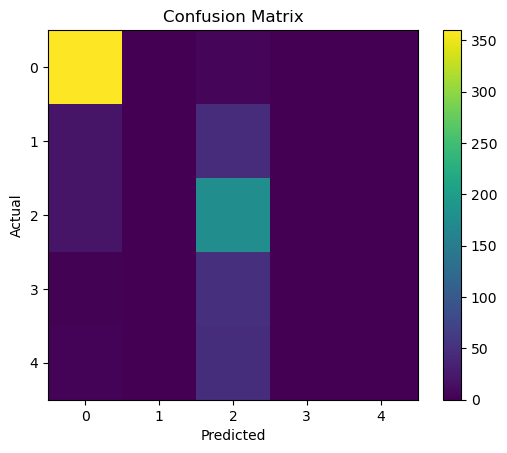

In [34]:
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [35]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       368
           1       0.00      0.00      0.00        67
           2       0.54      0.89      0.67       197
           3       0.00      0.00      0.00        51
           4       0.00      0.00      0.00        50

    accuracy                           0.73       733
   macro avg       0.29      0.37      0.32       733
weighted avg       0.59      0.73      0.65       733



c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [36]:
import pandas as pd

results_df = pd.DataFrame({
    "Actual": all_labels,
    "Predicted": all_preds
})

results_df.to_csv("validation_predictions.csv", index=False)
print("Predictions saved!")

Predictions saved!


App

In [42]:
!pip install timm

In [45]:
import torch
import timm

num_classes = 5   # IMPORTANT → your head shows 5 classes

model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=False,
    num_classes=num_classes
)

model.load_state_dict(torch.load("best_model.pth", map_location="cpu"))
model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [46]:
state_dict = torch.load("best_model.pth", map_location="cpu")
print(list(state_dict.keys())[:5])

['cls_token', 'pos_embed', 'patch_embed.proj.weight', 'patch_embed.proj.bias', 'blocks.0.norm1.weight']


In [53]:
import torch
import timm
from torchvision import transforms
from PIL import Image

# ----- CONFIG -----
num_classes = 5
class_names = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR"
] # CHANGE THIS

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----- Load Model -----
model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=False,
    num_classes=num_classes
)

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.to(device)
model.eval()

print("Model loaded successfully!")

Model loaded successfully!


Image Preprocessing

In [54]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Prediction Function

In [55]:
def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    return class_names[predicted.item()], confidence.item()

In [57]:
import os
print(os.getcwd())

c:\Users\DELL\AppData\Local\Programs\Microsoft VS Code


In [58]:
import os

folder = r"C:\Users\DELL\Downloads\aptos2019-blindness-detection\test_images"

# pick first image automatically
image_name = os.listdir(folder)[0]
image_path = os.path.join(folder, image_name)

print("Using image:", image_path)

label, conf = predict_image(image_path)
print(f"Prediction: {label}")
print(f"Confidence: {conf:.4f}")

Using image: C:\Users\DELL\Downloads\aptos2019-blindness-detection\test_images\0005cfc8afb6.png
Prediction: No DR
Confidence: 0.7940


In [60]:
import streamlit as st
import torch
import timm
from torchvision import transforms
from PIL import Image

num_classes = 5
class_names = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR"
] 

device = torch.device("cpu")

model = timm.create_model("vit_tiny_patch16_224", pretrained=False, num_classes=num_classes)
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

st.title("Vision Transformer Image Classifier")

uploaded_file = st.file_uploader("Upload an image", type=["jpg","png","jpeg"])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Uploaded Image", use_column_width=True)

    img_tensor = transform(image).unsqueeze(0)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        conf, pred = torch.max(probs, 1)

    st.write(f"Prediction: **{class_names[pred.item()]}**")
    st.write(f"Confidence: **{conf.item():.4f}**")

2026-02-23 23:54:56.931 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-23 23:54:56.932 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-23 23:54:56.933 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-23 23:54:56.933 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-23 23:54:56.934 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-23 23:54:56.934 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-23 23:54:56.935 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
